In [14]:
import geopandas as gpd
import pandas as pd
import ee
import os
import numpy as np
from pathlib import Path
from shapely.geometry import mapping
import geemap
from datetime import datetime

In [15]:
try:
    ee.Initialize(project='ee-biswajit001')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-biswajit001')

In [16]:
import sys
from pathlib import Path

# Add src directory to path so we can import geo_toolbox
# Go up two levels from notebooks directory to reach project root
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Python executable:", sys.executable)
print("Project root:", project_root)
print("src path:", src_path)
print("src exists:", src_path.exists())

Python executable: d:\Personal Projects\geo_toolbox\.venv\Scripts\python.exe
Project root: d:\Personal Projects\geo_toolbox
src path: d:\Personal Projects\geo_toolbox\src
src exists: True


In [17]:
from geo_toolbox import GEETimeSeriesExtractor, TimeSeriesProcessor, TimeSeriesPlotter

In [21]:
cwd = Path.cwd().parent
farm_file_path = Path.joinpath(cwd, r'data\input\farm1.gpkg')
gdf = gpd.read_file(farm_file_path)

In [ ]:
gdf.head()

,Shape_Area,AREA,geometry
0,0.0,16.117602,"POLYGON ((35.38742 -11.44702, 35.38624 -11.445..."


In [25]:
my_farm_geometry = geemap.gdf_to_ee(gdf).geometry()

In [26]:
# 1. Initialize the Extractor
extractor = GEETimeSeriesExtractor()

# 2. Fetch data: We want standard NDVI, but also a custom Soil Moisture proxy
# raw_df = extractor.extract(
#     aoi=my_farm_geometry,
#     start_date='2025-06-01',
#     # end_date='2026-04-01',
#     end_date=datetime.now().strftime('%Y-%m-%d'), # Dynamic end date
#     indices=['NDVI', 'NDTI'], 
#     # custom_formulas={'CUSTOM_RATIO': 'b("B3") / b("B12")'}, # Dynamic!
#     apply_mask=True # Toggle cloud masking
# )
raw_df = extractor.extract(
    aoi=my_farm_geometry,
    start_date='2025-10-01',
    indices=['NDVI', 'NDTI'],
    end_date=datetime.now().strftime('%Y-%m-%d'),
    reducer='median',          # Passing string instead of Enum
    crs='EPSG:4326',        # Caught by **reduce_kwargs
    # bestEffort=True         # Caught by **reduce_kwargs
)
# 3. Process the data: Let's aggregate by Fortnight (2 Weeks)
processor = TimeSeriesProcessor(raw_df)
processed_df = processor.aggregate(frequency='2W').df

# 4. Plot the data: Let's use Plotly for an interactive dashboard
plotter = TimeSeriesPlotter(processed_df)
plotter.plot_interactive(columns_to_plot=['NDVI', 'NDTI', 'CUSTOM_RATIO'], title="Farm 402 - Fortnightly Dynamics")

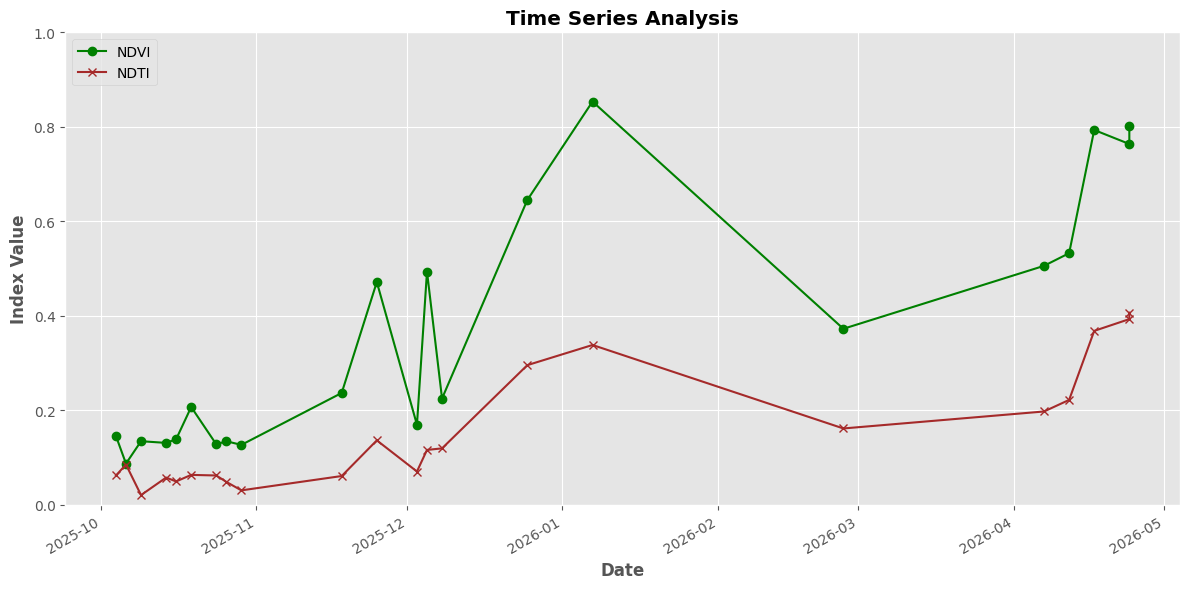

In [27]:
TimeSeriesPlotter(raw_df).plot_static(columns_to_plot=['NDVI', 'NDTI'], ylim=(0,1), style_dict={'NDVI': {'color': 'green', 'marker': 'o'}, 'NDTI': {'color': 'brown', 'marker': 'x'}}, save_file_path=r'example_data\output\farm1_time_series.png')

In [28]:
# date, smooth_ndvi = processor.smooth_series('NDVI')
# smooth_df = pd.DataFrame({'date': date, 'smooth_ndvi': smooth_ndvi})
# TimeSeriesPlotter(smooth_df).plot_interactive(columns_to_plot=['smooth_ndvi'], title="Smoothed NDVI")

In [29]:
# Define Plotly-specific styling for the traces
plotly_styles = {
    'NDVI': {
        'line_color': 'green', 
        'mode': 'lines+markers', 
        'line_width': 3
    },
    'NDTI': {
        'line_color': 'orange', 
        'mode': 'lines', 
        'line_dash': 'dash' # Makes it a dashed line
    }
}

# Generate the interactive plot
plotter.plot_interactive(
    columns_to_plot=['NDVI', 'NDTI'],
    title="Farm 402 - Interactive Dynamics",
    style_dict=plotly_styles,
    
    # Everything below here is captured by **layout_kwargs and sent to update_layout()
    height=600,
    width=800,
    # xaxis_range=['2025-10-01', '2026-04-01'],
    yaxis_range=[0, 1],
    yaxis_title="Vegetation Indices",
    showlegend=True,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01) # Puts legend inside the plot
)

In [30]:
# 1. Process everything in one elegant chain
processed_df = (TimeSeriesProcessor(raw_df)
                # .aggregate(frequency='D')
                .smooth_series('NDVI', sigma=10)
                # .smooth_series('NDTI', sigma=10)
                .df) # Extract the final dataframe at the end

# 2. Define your styles (Plotly will plot the raw data as dots, and smoothed as lines)
styles = {
    'NDVI': {'mode': 'markers', 'marker_color': 'lightgreen', 'name': 'Raw NDVI'},
    'NDVI_smoothed': {'mode': 'lines', 'line_color': 'darkgreen', 'line_width': 3, 'name': 'Smoothed NDVI'},
}

# 3. Plot it instantly
plotter = TimeSeriesPlotter(processed_df)
plotter.plot_interactive(
    columns_to_plot=['NDVI', 'NDVI_smoothed'], 
    title="Farm 402 - Raw vs Smoothed NDVI",
    style_dict=styles
)

Notice: Duplicate dates found (likely overlapping tiles). Averaging duplicates...
